# Ropedia Academy — B6 · Making NeRF fast: hash grids

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/B6.ipynb)

> **Builds the multi-resolution hash encoding and visualizes each level's feature field over a slice — the coarse→fine grid structure behind Instant-NGP's speed.**
>
> 搭出多分辨率哈希编码，并把每个层级的特征场在切片上可视化——这正是 Instant-NGP 提速背后的由粗到细网格结构。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/B6

feature dim per point: 8 (read by a tiny MLP)


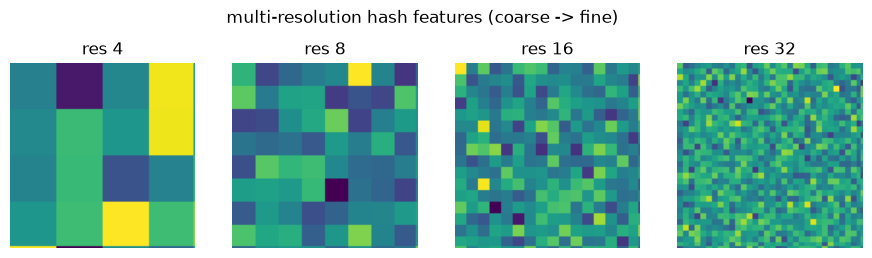

In [1]:
import torch, torch.nn as nn, matplotlib.pyplot as plt
# Instant-NGP: capacity in a multi-resolution hash grid read by a tiny MLP.

# ---------- INPUT: learnable feature tables (one per resolution level) ----------
L, Tsize, Fdim = 4, 2**14, 2
resolutions = [4, 8, 16, 32]
tables = nn.ParameterList([nn.Parameter(torch.randn(Tsize, Fdim)) for _ in range(L)])
primes = torch.tensor([1, 2654435761, 805459861])

# ---------- MODEL: per-point local cell lookup + spatial hash ----------
def hash_encode(x):                                # x in [0,1]^3 -> features
    feats = []
    for table, res in zip(tables, resolutions):
        cell = (x * res).long()                     # local grid cell (cheap, local)
        idx  = (cell * primes).sum(-1) % Tsize      # spatial hash (collisions tolerated)
        feats.append(table[idx])
    return torch.cat(feats, -1)

# ---------- OUTPUT: feature dim + each level's field over a slice (coarse->fine) ----------
print("feature dim per point:", L*Fdim, "(read by a tiny MLP)")
gx = torch.stack(torch.meshgrid(torch.linspace(0,1,96), torch.linspace(0,1,96),
                                indexing='ij'), -1)
g3 = torch.cat([gx, torch.zeros(96,96,1)], -1).reshape(-1,3)
fig, ax = plt.subplots(1, L, figsize=(11, 3))
for lvl in range(L):
    cell = (g3 * resolutions[lvl]).long(); idx = (cell * primes).sum(-1) % Tsize
    ax[lvl].imshow(tables[lvl][idx][:,0].detach().reshape(96,96), cmap='viridis')
    ax[lvl].set_title(f"res {resolutions[lvl]}"); ax[lvl].axis('off')
plt.suptitle("multi-resolution hash features (coarse -> fine)"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/B6
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks